Total Titles : 7689
Movies       : 5377
TV Shows     : 2312


FileNotFoundError: [Errno 2] No such file or directory: './charts/movies_vs_tvshows.png'

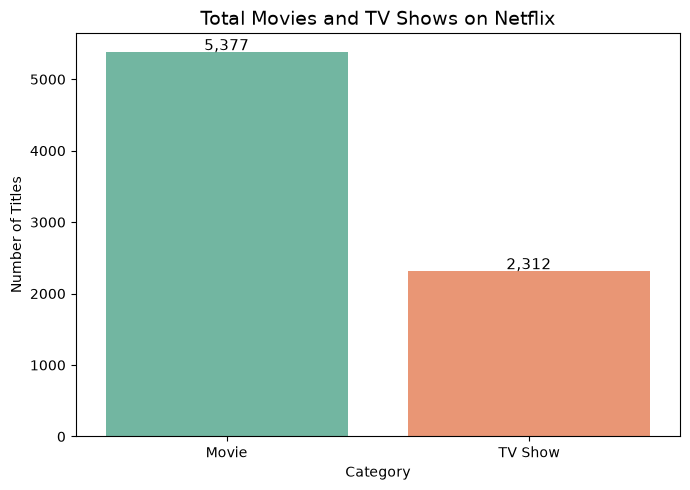

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("./Data/cleaned_netflix.csv")

category_count = (
    df["Category"]
    .value_counts()
    .reset_index()
)

category_count.columns = ["Category", "Count"]

category_count

total_movies = category_count.loc[
    category_count["Category"] == "Movie",
    "Count"
].values[0]

total_tvshows = category_count.loc[
    category_count["Category"] == "TV Show",
    "Count"
].values[0]

total_titles = len(df)

print(f"Total Titles : {total_titles}")
print(f"Movies       : {total_movies}")
print(f"TV Shows     : {total_tvshows}")

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7,5))

sns.barplot(
    data=category_count,
    x="Category",
    y="Count",
    hue="Category",      # avoids future seaborn warnings
    palette="Set2",
    legend=False,
    ax=ax
)

ax.set_title("Total Movies and TV Shows on Netflix", fontsize=14)

ax.set_xlabel("Category")

ax.set_ylabel("Number of Titles")

for i, value in enumerate(category_count["Count"]):
    ax.text(
        i,
        value + 30,
        f"{value:,}",
        ha="center",
        fontsize=11
    )

plt.tight_layout()

plt.savefig("./charts/movies_vs_tvshows.png", dpi=300)

plt.show()

Movie Percentage : 69.93%
TV Show Percentage : 30.07%


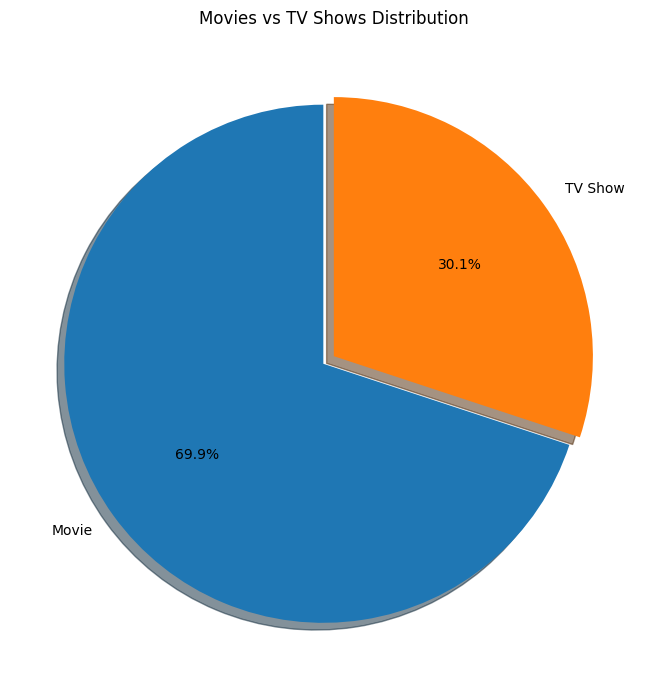

In [4]:
category_percentage = (
    df["Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

category_percentage.columns = ["Category", "Percentage"]

category_percentage

movie_percentage = category_percentage.loc[
    category_percentage["Category"] == "Movie",
    "Percentage"
].values[0]

tvshow_percentage = category_percentage.loc[
    category_percentage["Category"] == "TV Show",
    "Percentage"
].values[0]

print(f"Movie Percentage : {movie_percentage}%")
print(f"TV Show Percentage : {tvshow_percentage}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.pie(
    category_percentage["Percentage"],
    labels=category_percentage["Category"],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05, 0],
    shadow=True
)

plt.title("Movies vs TV Shows Distribution")

plt.tight_layout()

plt.savefig("./charts/movies_vs_tvshows_percentage.png", dpi=300)

plt.show()

Top Country : United States
Total Titles : 3249


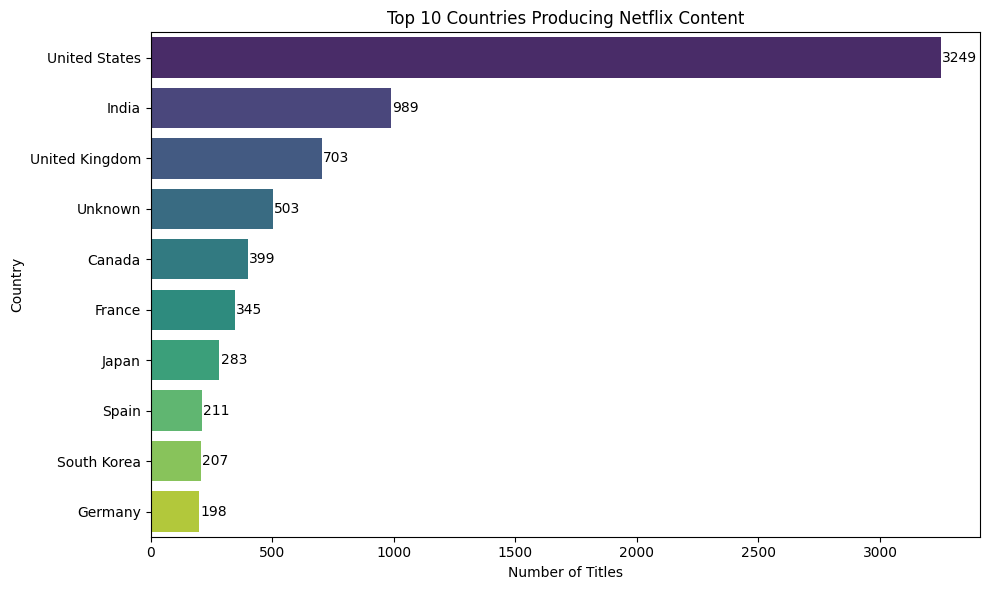

In [5]:
top_countries = (
    df["Country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
    .reset_index()
)

top_countries.columns = ["Country", "Content Count"]

top_countries

top_country = top_countries.iloc[0]["Country"]
top_country_count = top_countries.iloc[0]["Content Count"]

print("Top Country :", top_country)
print("Total Titles :", top_country_count)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=top_countries,
    y="Country",
    x="Content Count",
    hue="Country",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title("Top 10 Countries Producing Netflix Content")

ax.set_xlabel("Number of Titles")

ax.set_ylabel("Country")

for i, value in enumerate(top_countries["Content Count"]):
    ax.text(
        value + 5,
        i,
        str(value),
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig("./charts/top10_countries.png", dpi=300)

plt.show()

Top Director : Jan Suter
Titles Directed : 21


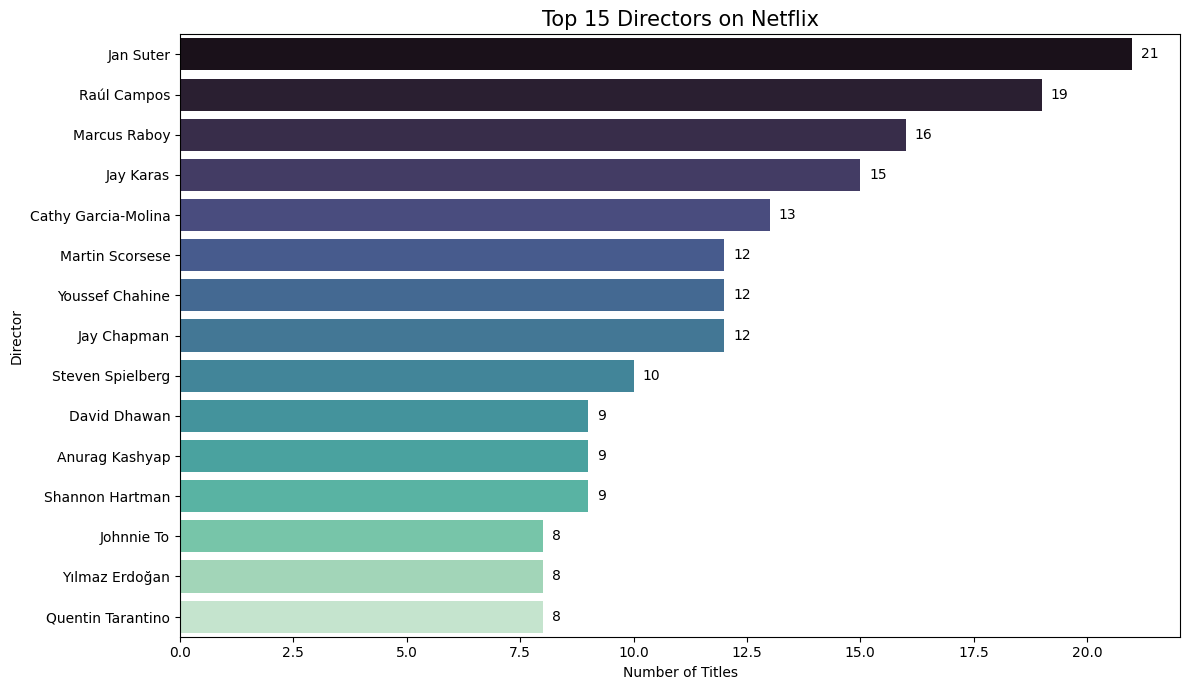

In [6]:
top_directors = (
    df["Director"]
    .dropna()
    .replace("Unknown", pd.NA)
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(15)
    .reset_index()
)

top_directors.columns = ["Director", "Title Count"]

top_directors

top_director = top_directors.iloc[0]["Director"]

top_director_count = top_directors.iloc[0]["Title Count"]

print("Top Director :", top_director)
print("Titles Directed :", top_director_count)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,7))

sns.barplot(
    data=top_directors,
    x="Title Count",
    y="Director",
    hue="Director",
    palette="mako",
    legend=False,
    ax=ax
)

ax.set_title("Top 15 Directors on Netflix", fontsize=15)

ax.set_xlabel("Number of Titles")

ax.set_ylabel("Director")

for i, value in enumerate(top_directors["Title Count"]):
    ax.text(
        value + 0.2,
        i,
        str(value),
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig("./charts/top15_directors.png", dpi=300)

plt.show()

Most Common Rating : TV-MA
Total Titles : 2839


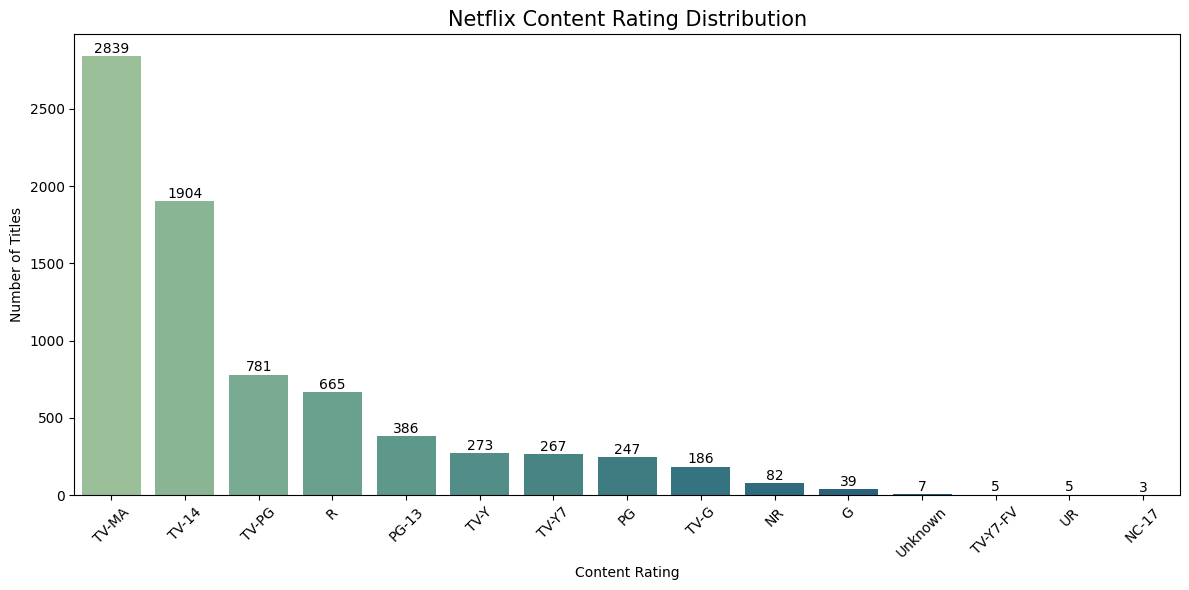

In [7]:
rating_distribution = (
    df["Rating"]
    .dropna()
    .value_counts()
    .reset_index()
)

rating_distribution.columns = ["Rating", "Count"]

rating_distribution

top_rating = rating_distribution.iloc[0]["Rating"]

top_rating_count = rating_distribution.iloc[0]["Count"]

print("Most Common Rating :", top_rating)
print("Total Titles :", top_rating_count)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=rating_distribution,
    x="Rating",
    y="Count",
    hue="Rating",
    palette="crest",
    legend=False,
    ax=ax
)

ax.set_title("Netflix Content Rating Distribution", fontsize=15)

ax.set_xlabel("Content Rating")

ax.set_ylabel("Number of Titles")

plt.xticks(rotation=45)

# Value labels
for i, value in enumerate(rating_distribution["Count"]):
    ax.text(
        i,
        value + 20,
        str(value),
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig("./charts/content_rating_distribution.png", dpi=300)

plt.show()

Oldest Release Year : Action & Adventure
Latest Release Year : Thrillers


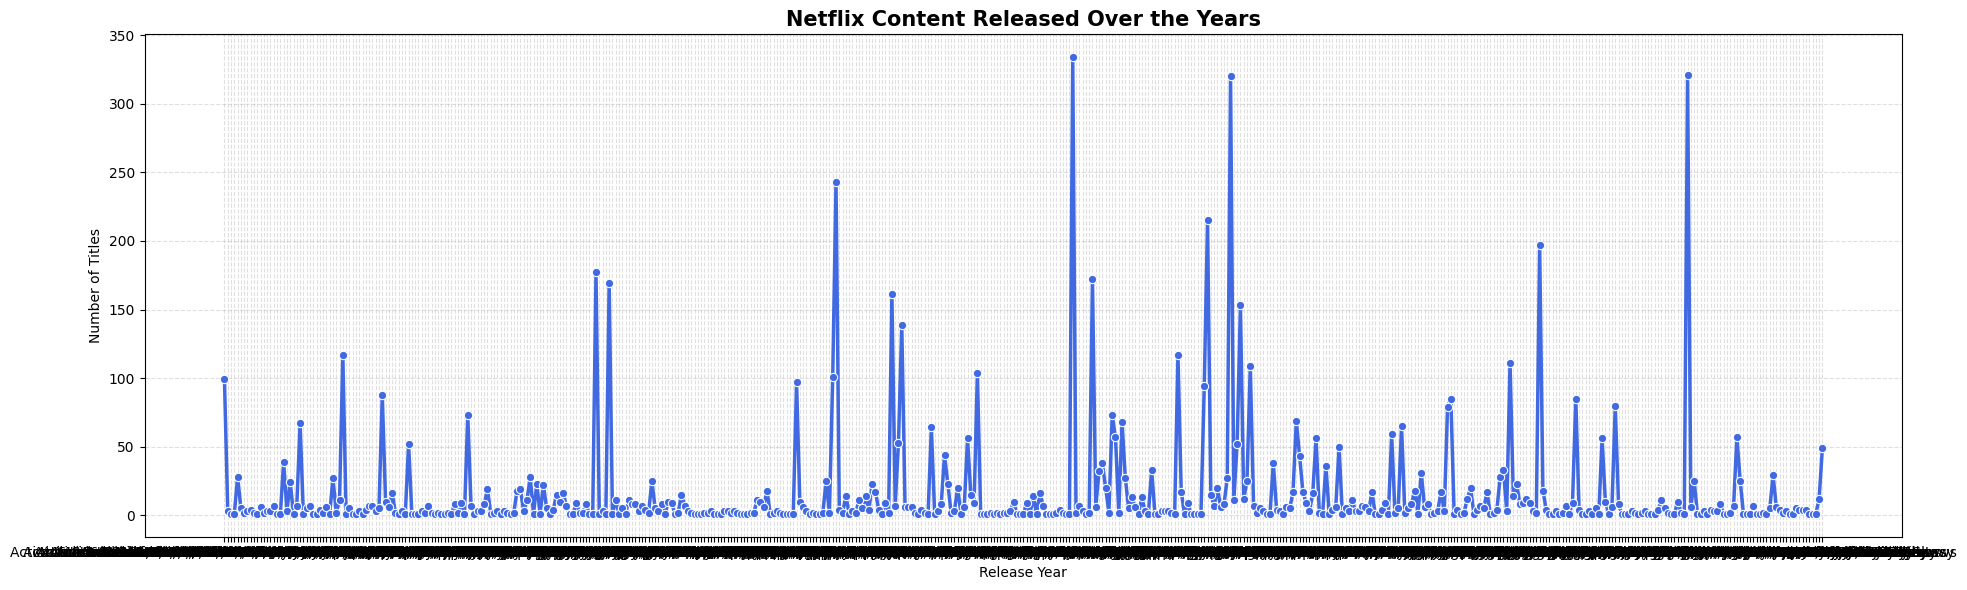

In [9]:
release_trend = (
    df.groupby("Type")
      .size()
      .reset_index(name="Total Titles")
      .sort_values("Type")
)

release_trend.head()

latest_year = release_trend["Type"].max()

oldest_year = release_trend["Type"].min()

print("Oldest Release Year :", oldest_year)
print("Latest Release Year :", latest_year)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(20,6))

sns.lineplot(
    data=release_trend,
    x="Type",
    y="Total Titles",
    marker="o",
    linewidth=2.5,
    color="royalblue",
    ax=ax
)

ax.set_title(
    "Netflix Content Released Over the Years",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Release Year")

ax.set_ylabel("Number of Titles")

ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig("./charts/release_year_trend.png", dpi=300)

plt.show()

Peak Release Year : Documentaries
Total Titles Released : 334


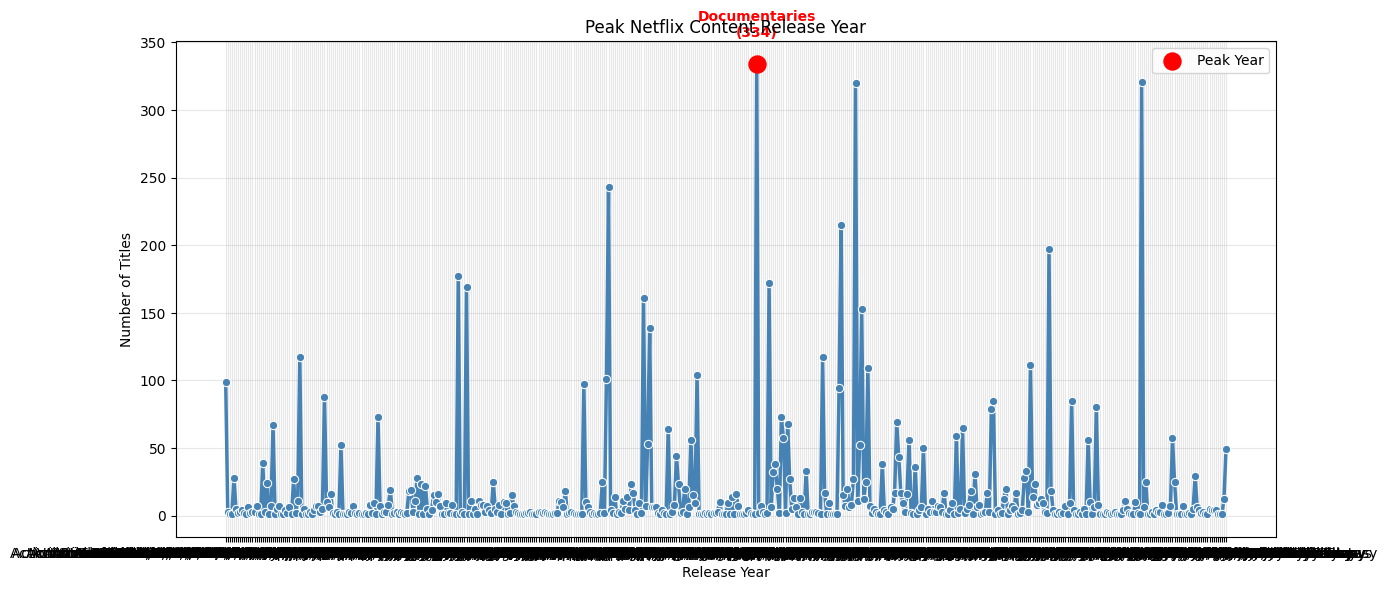

In [10]:
peak_year = release_trend.loc[
    release_trend["Total Titles"].idxmax()
]

peak_year

peak_release_year = peak_year["Type"]

peak_release_count = peak_year["Total Titles"]

print(f"Peak Release Year : {peak_release_year}")

print(f"Total Titles Released : {peak_release_count}")

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14,6))

sns.lineplot(
    data=release_trend,
    x="Type",
    y="Total Titles",
    marker="o",
    linewidth=2.5,
    color="steelblue",
    ax=ax
)

# Highlight peak year
ax.scatter(
    peak_release_year,
    peak_release_count,
    color="red",
    s=150,
    zorder=5,
    label="Peak Year"
)

ax.text(
    peak_release_year,
    peak_release_count + 20,
    f"{peak_release_year}\n({peak_release_count})",
    ha="center",
    color="red",
    fontsize=10,
    fontweight="bold"
)

ax.set_title("Peak Netflix Content Release Year")

ax.set_xlabel("Release Year")

ax.set_ylabel("Number of Titles")

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("./charts/peak_release_year.png", dpi=300)

plt.show()

🎬 Longest Movie Details

Title       : Black Mirror: Bandersnatch
Director    : Unknown
Country     : United States
Release Year: Dramas, International Movies, Sci-Fi & Fantasy
Duration    : 312 Minutes
Rating      : TV-MA


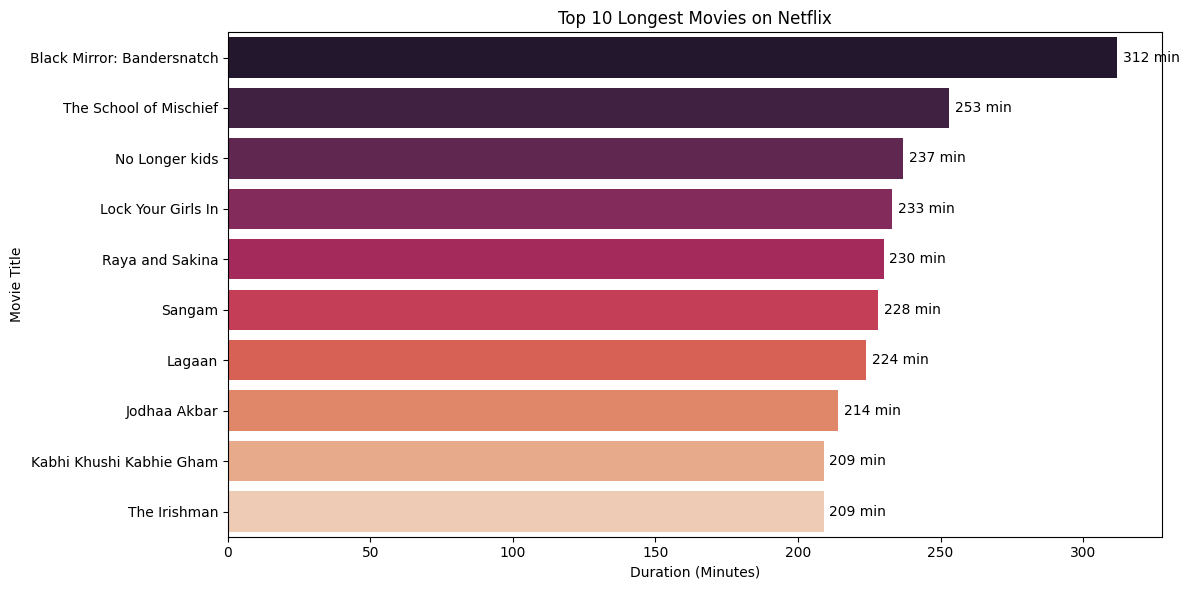

In [12]:
movies = df[df["Category"] == "Movie"].copy()

movies["Minutes"] = (
    movies["Duration"]
    .str.replace(" min", "", regex=False)
    .astype(int)
)

movies.head()

longest_movie = movies.loc[
    movies["Minutes"].idxmax()
]

longest_movie

print("🎬 Longest Movie Details\n")

print(f"Title       : {longest_movie['Title']}")
print(f"Director    : {longest_movie['Director']}")
print(f"Country     : {longest_movie['Country']}")
print(f"Release Year: {longest_movie['Type']}")
print(f"Duration    : {longest_movie['Minutes']} Minutes")
print(f"Rating      : {longest_movie['Rating']}")

top10_longest = (
    movies[
        [
            "Title",
            "Minutes",
            "Director",
            "Country"
        ]
    ]
    .sort_values(
        by="Minutes",
        ascending=False
    )
    .head(10)
)

top10_longest

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=top10_longest,
    y="Title",
    x="Minutes",
    hue="Title",
    palette="rocket",
    legend=False,
    ax=ax
)

ax.set_title("Top 10 Longest Movies on Netflix")

ax.set_xlabel("Duration (Minutes)")

ax.set_ylabel("Movie Title")

for i, value in enumerate(top10_longest["Minutes"]):
    ax.text(
        value + 2,
        i,
        f"{value} min",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig("./charts/top10_longest_movies.png", dpi=300)

plt.show()

Average Movie Duration : 99.31 Minutes


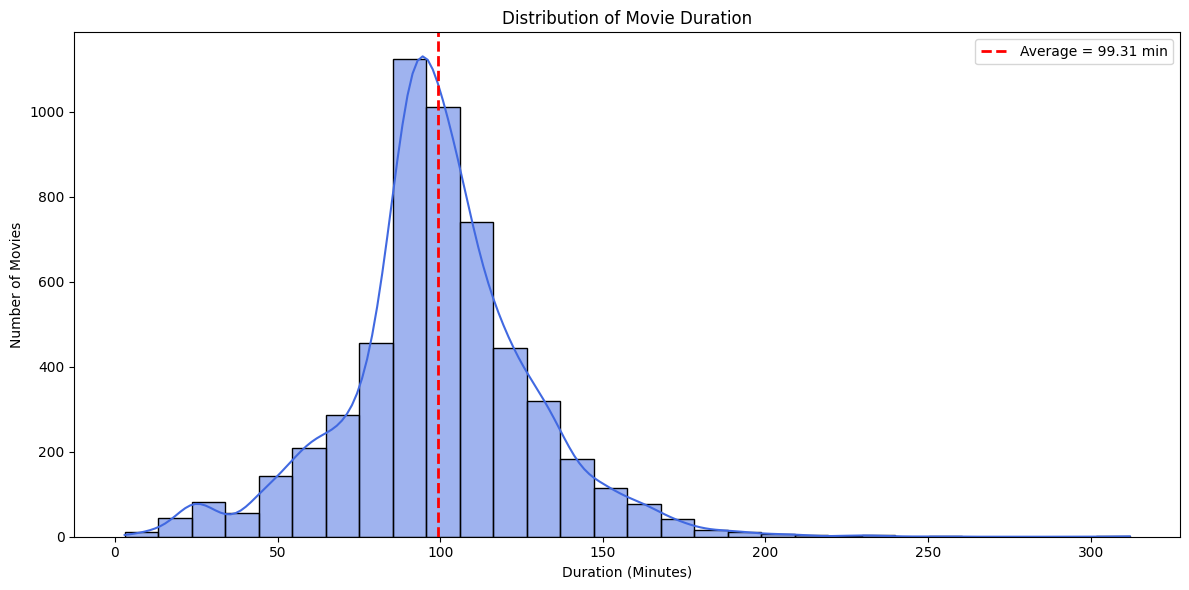

In [13]:
average_duration = movies["Minutes"].mean()

print(f"Average Movie Duration : {average_duration:.2f} Minutes")

movies["Minutes"].describe()

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,6))

sns.histplot(
    data=movies,
    x="Minutes",
    bins=30,
    kde=True,
    color="royalblue",
    ax=ax
)

ax.axvline(
    average_duration,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average = {average_duration:.2f} min"
)

ax.set_title("Distribution of Movie Duration")

ax.set_xlabel("Duration (Minutes)")

ax.set_ylabel("Number of Movies")

ax.legend()

plt.tight_layout()

plt.savefig("./charts/movie_duration_distribution.png", dpi=300)

plt.show()

Most Frequent Actor : Anupam Kher
Total Titles : 42


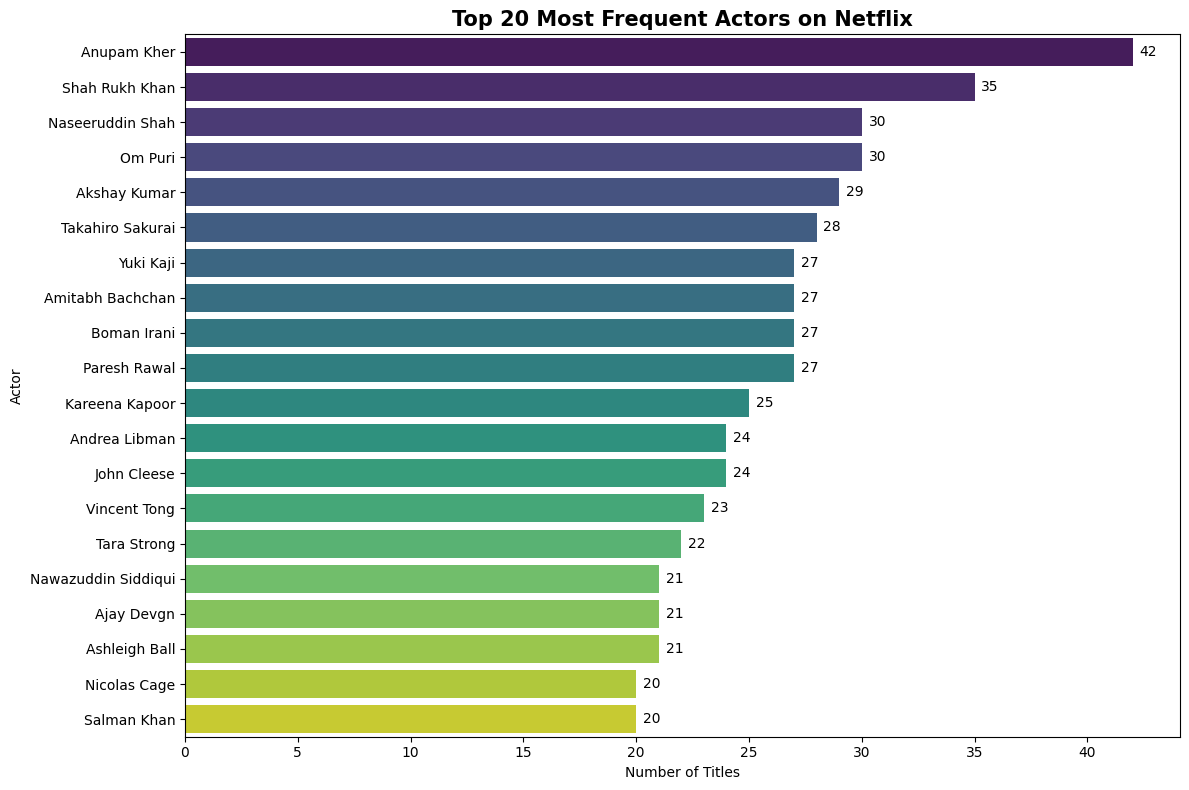

In [15]:
top_actors = (
    df["Cast"]
    .dropna()
    .replace("Unknown", pd.NA)
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(20)
    .reset_index()
)

top_actors.columns = ["Actor", "Title Count"]

top_actors

top_actor = top_actors.iloc[0]["Actor"]

top_actor_count = top_actors.iloc[0]["Title Count"]

print(f"Most Frequent Actor : {top_actor}")

print(f"Total Titles : {top_actor_count}")

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,8))

sns.barplot(
    data=top_actors,
    x="Title Count",
    y="Actor",
    hue="Actor",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 20 Most Frequent Actors on Netflix",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Number of Titles")

ax.set_ylabel("Actor")

for i, value in enumerate(top_actors["Title Count"]):
    ax.text(
        value + 0.3,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.savefig("./charts/top20_actors.png", dpi=300)

plt.show()

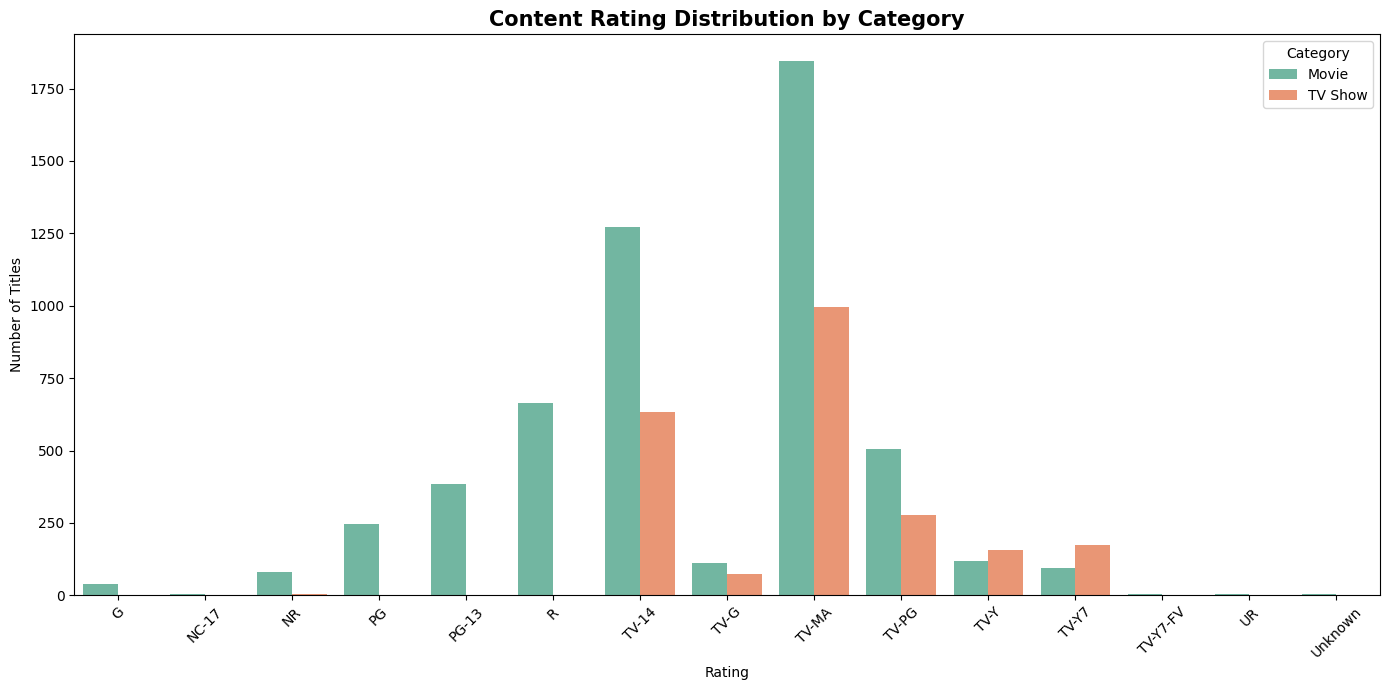

In [16]:
rating_category = (
    df.groupby(["Category", "Rating"])
      .size()
      .reset_index(name="Count")
)

rating_category.head()

rating_pivot = (
    rating_category
    .pivot(
        index="Rating",
        columns="Category",
        values="Count"
    )
    .fillna(0)
)

rating_pivot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.barplot(
    data=rating_category,
    x="Rating",
    y="Count",
    hue="Category",
    palette="Set2"
)

plt.title(
    "Content Rating Distribution by Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Rating")

plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.legend(title="Category")

plt.tight_layout()

plt.savefig(
    "./charts/rating_distribution_category.png",
    dpi=300
)

plt.show()

Countries Producing Both Movies and TV Shows :
59


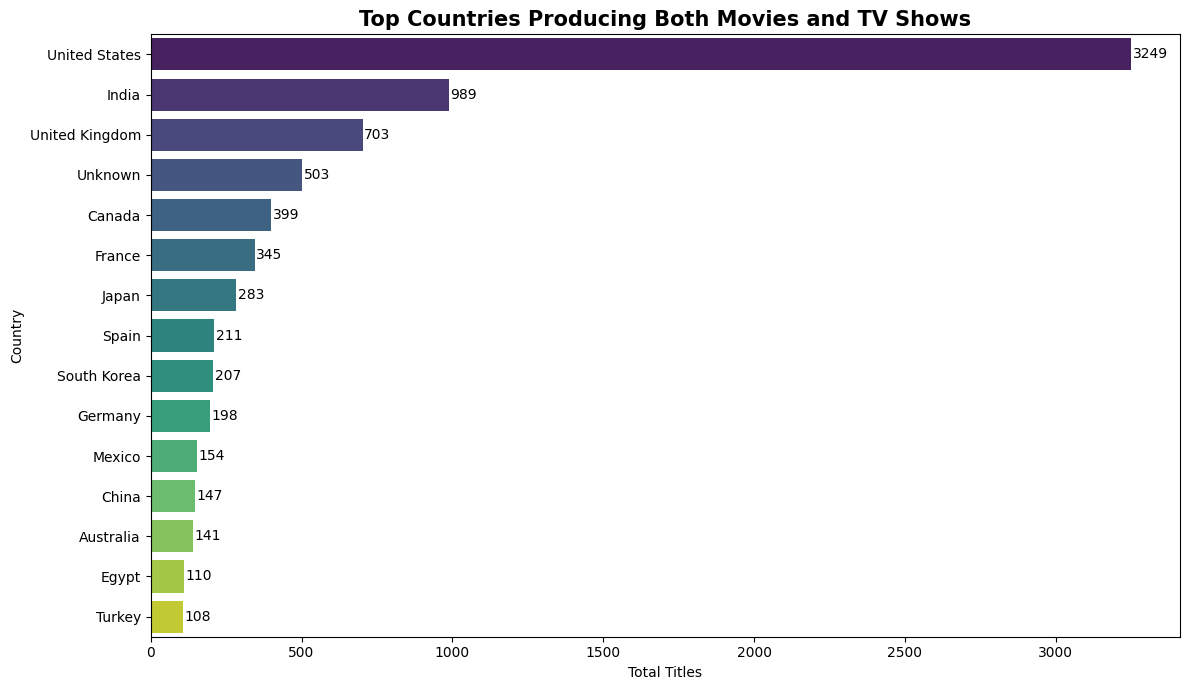

In [17]:
country_category = (
    df.dropna(subset=["Country"])
      .assign(Country=df["Country"].str.split(", "))
      .explode("Country")
)

country_category.head()

country_type = (
    country_category.groupby("Country")["Category"]
    .nunique()
    .reset_index()
)

country_type.head()

both_categories = (
    country_type[
        country_type["Category"] == 2
    ]
)

both_categories

print("Countries Producing Both Movies and TV Shows :")

print(len(both_categories))

both_categories.sort_values("Country")

country_titles = (
    country_category[
        country_category["Country"].isin(both_categories["Country"])
    ]
    .groupby("Country")
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Total Titles")
)

country_titles

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,7))

sns.barplot(
    data=country_titles,
    x="Total Titles",
    y="Country",
    hue="Country",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top Countries Producing Both Movies and TV Shows",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Total Titles")

ax.set_ylabel("Country")

for i, value in enumerate(country_titles["Total Titles"]):
    ax.text(
        value + 5,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "./charts/countries_movies_tvshows.png",
    dpi=300
)

plt.show()

Highest Release Month : December
Titles Released : 817


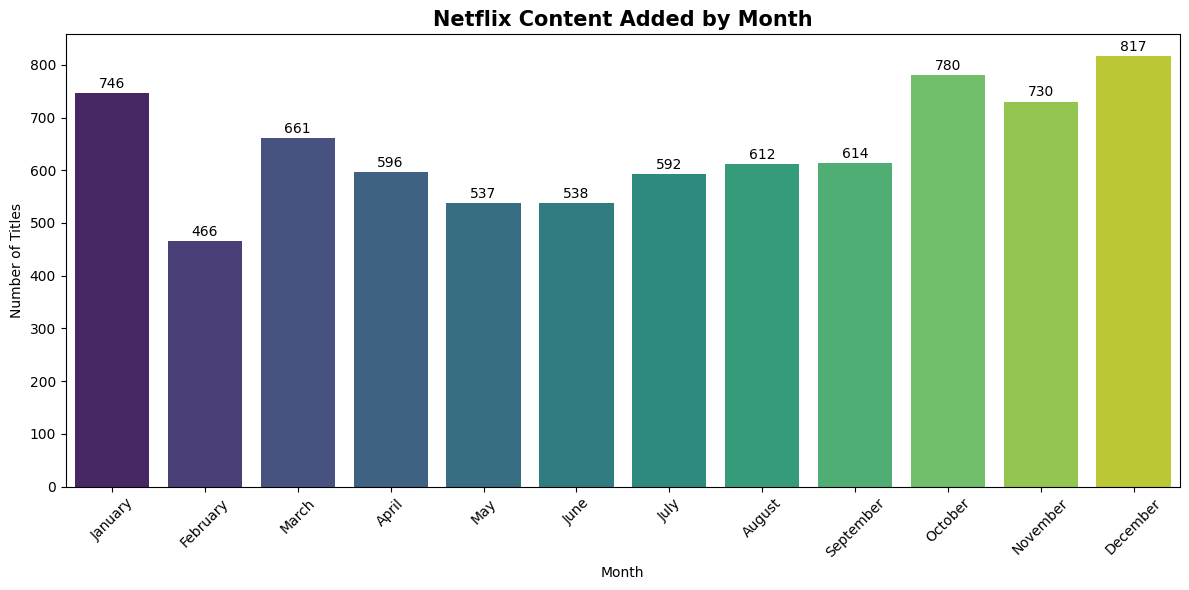

In [19]:
df["Release_Date"] = pd.to_datetime(
    df["Release_Date"],
    errors="coerce"
)

df["Release Month"] = df["Release_Date"].dt.month_name()

df[["Release_Date", "Release Month"]].head()

monthly_release = (
    df["Release Month"]
    .value_counts()
    .reindex([
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ])
    .reset_index()
)

monthly_release.columns = ["Month", "Total Titles"]

monthly_release

peak_month = monthly_release.loc[
    monthly_release["Total Titles"].idxmax()
]

peak_month

highest_release_month = peak_month["Month"]

highest_release_count = peak_month["Total Titles"]

print(f"Highest Release Month : {highest_release_month}")

print(f"Titles Released : {highest_release_count}")

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=monthly_release,
    x="Month",
    y="Total Titles",
    hue="Month",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title(
    "Netflix Content Added by Month",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Month")

ax.set_ylabel("Number of Titles")

plt.xticks(rotation=45)

for i, value in enumerate(monthly_release["Total Titles"]):
    ax.text(
        i,
        value + 10,
        str(int(value)),
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "./charts/monthly_release_trend.png",
    dpi=300
)

plt.show()

In [23]:
# -------------------------------------------------------
# 14. Missing Value Analysis
# -------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create Missing Value Summary
missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage (%)": (
        df.isnull().sum() / len(df) * 100
    ).round(2).values
})

# Sort by missing values
missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)

# Total Missing Values
total_missing = missing_summary["Missing Values"].sum()

print(f"Total Missing Values : {total_missing}")

# -------------------------------------------------------
# Visualization
# -------------------------------------------------------

if total_missing == 0:
    print("✅ No missing values found in the cleaned dataset.")
else:
    fig, ax = plt.subplots(figsize=(16, 7))

    sns.barplot(
        data=missing_summary,
        x="Column",
        y="Missing Values",
        hue="Column",
        palette="Reds",
        legend=False,
        ax=ax
    )

    ax.set_title(
        "Missing Values by Column",
        fontsize=16,
        fontweight="bold"
    )

    ax.set_xlabel("Columns")
    ax.set_ylabel("Missing Values")

    ax.tick_params(axis="x", rotation=45)

    # Add value labels
    for i, value in enumerate(missing_summary["Missing Values"]):
        ax.text(
            i,
            value + 0.5,
            str(value),
            ha="center",
            fontsize=10
        )

    plt.tight_layout()

    plt.savefig(
        "./charts/missing_value_analysis.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

,Column,Missing Values,Missing Percentage (%)
0,Show_Id,0,0.0
1,Category,0,0.0
2,Title,0,0.0
3,Director,0,0.0
4,Cast,0,0.0
5,Country,0,0.0
6,Release_Date,0,0.0
7,Rating,0,0.0
8,Duration,0,0.0
9,Type,0,0.0


Total Missing Values : 0
✅ No missing values found in the cleaned dataset.


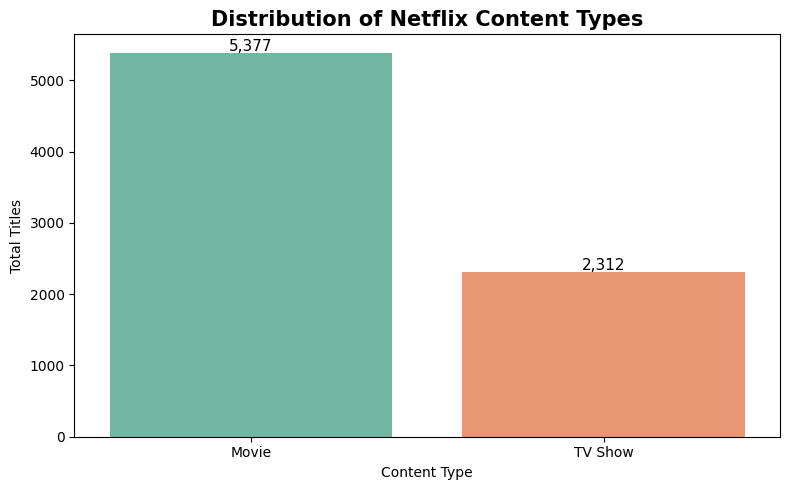

In [24]:
content_distribution = (
    df["Category"]
    .value_counts()
    .reset_index()
)

content_distribution.columns = [
    "Content Type",
    "Total Titles"
]

content_distribution

content_distribution["Percentage"] = (
    content_distribution["Total Titles"]
    / content_distribution["Total Titles"].sum()
    * 100
).round(2)

content_distribution

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    data=content_distribution,
    x="Content Type",
    y="Total Titles",
    hue="Content Type",
    palette="Set2",
    legend=False,
    ax=ax
)

ax.set_title(
    "Distribution of Netflix Content Types",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Content Type")
ax.set_ylabel("Total Titles")

for i, value in enumerate(content_distribution["Total Titles"]):
    ax.text(
        i,
        value + 30,
        f"{value:,}",
        ha="center",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "./charts/content_distribution_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Total Unique Directors : 4047
Top Director : Jan Suter
Titles Directed : 21


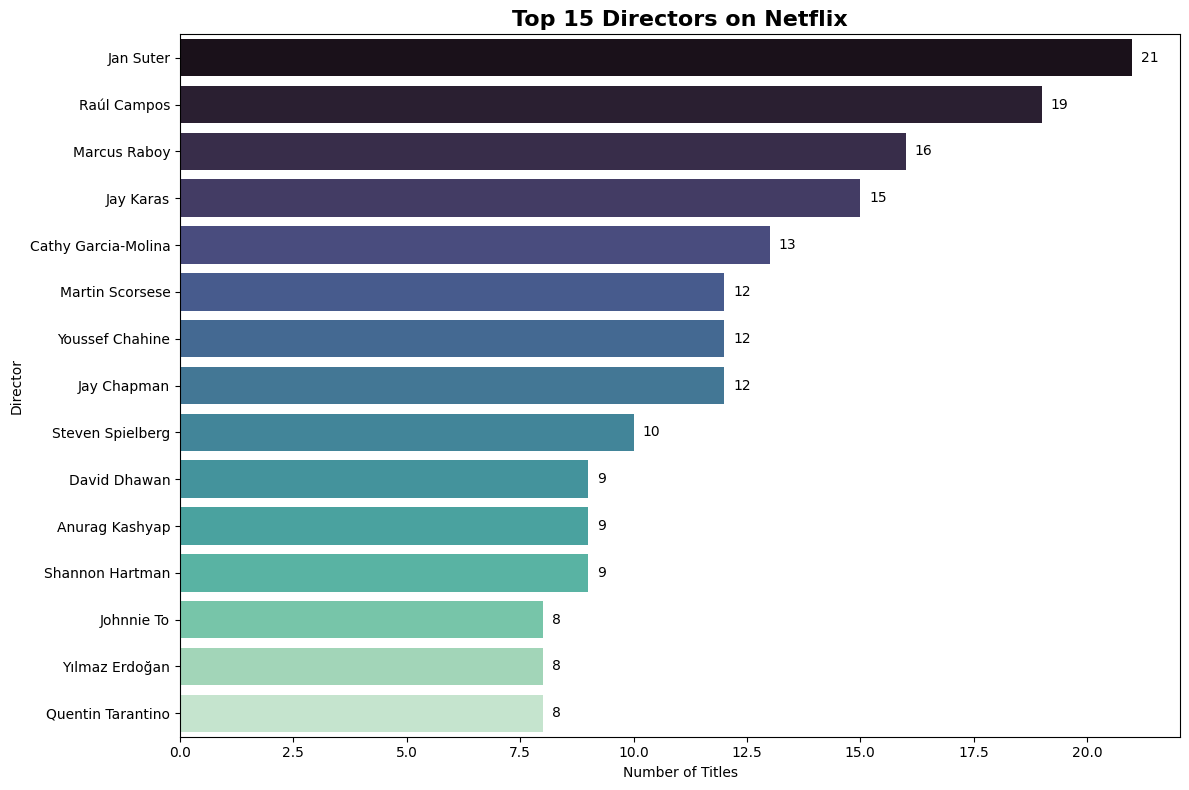

In [25]:
top15_directors = (
    df["Director"]
    .dropna()
    .replace("Unknown", pd.NA)
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(15)
    .reset_index()
)

top15_directors.columns = [
    "Director",
    "Total Titles"
]

top15_directors

print(f"Total Unique Directors : {df['Director'].nunique()}")

print(f"Top Director : {top15_directors.iloc[0]['Director']}")

print(f"Titles Directed : {top15_directors.iloc[0]['Total Titles']}")

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,8))

sns.barplot(
    data=top15_directors,
    x="Total Titles",
    y="Director",
    hue="Director",
    palette="mako",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 15 Directors on Netflix",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Number of Titles")

ax.set_ylabel("Director")

for i, value in enumerate(top15_directors["Total Titles"]):
    ax.text(
        value + 0.2,
        i,
        str(value),
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "./charts/top15_directors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

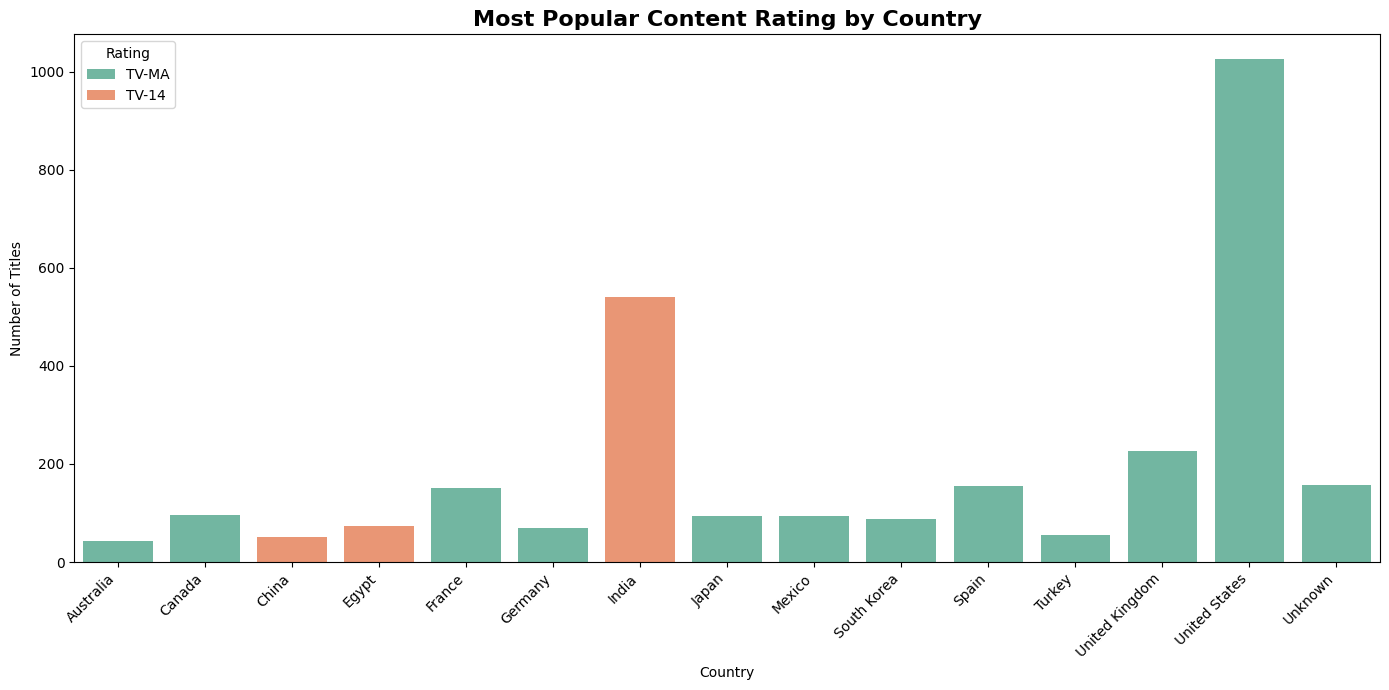

In [26]:
country_rating = (
    df.dropna(subset=["Country", "Rating"])
      .assign(Country=df["Country"].str.split(", "))
      .explode("Country")
)

country_rating.head()

country_rating_count = (
    country_rating
    .groupby(["Country", "Rating"])
    .size()
    .reset_index(name="Count")
)

country_rating_count.head()

popular_rating = (
    country_rating_count
    .sort_values(
        ["Country", "Count"],
        ascending=[True, False]
    )
    .groupby("Country")
    .first()
    .reset_index()
)

popular_rating.head(15)

top15_country_rating = (
    country_rating
    .groupby("Country")
    .size()
    .sort_values(ascending=False)
    .head(15)
    .index
)

popular_rating_top15 = popular_rating[
    popular_rating["Country"].isin(top15_country_rating)
]

popular_rating_top15

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14,7))

sns.barplot(
    data=popular_rating_top15,
    x="Country",
    y="Count",
    hue="Rating",
    palette="Set2",
    ax=ax
)

ax.set_title(
    "Most Popular Content Rating by Country",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Country")
ax.set_ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "./charts/popular_rating_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

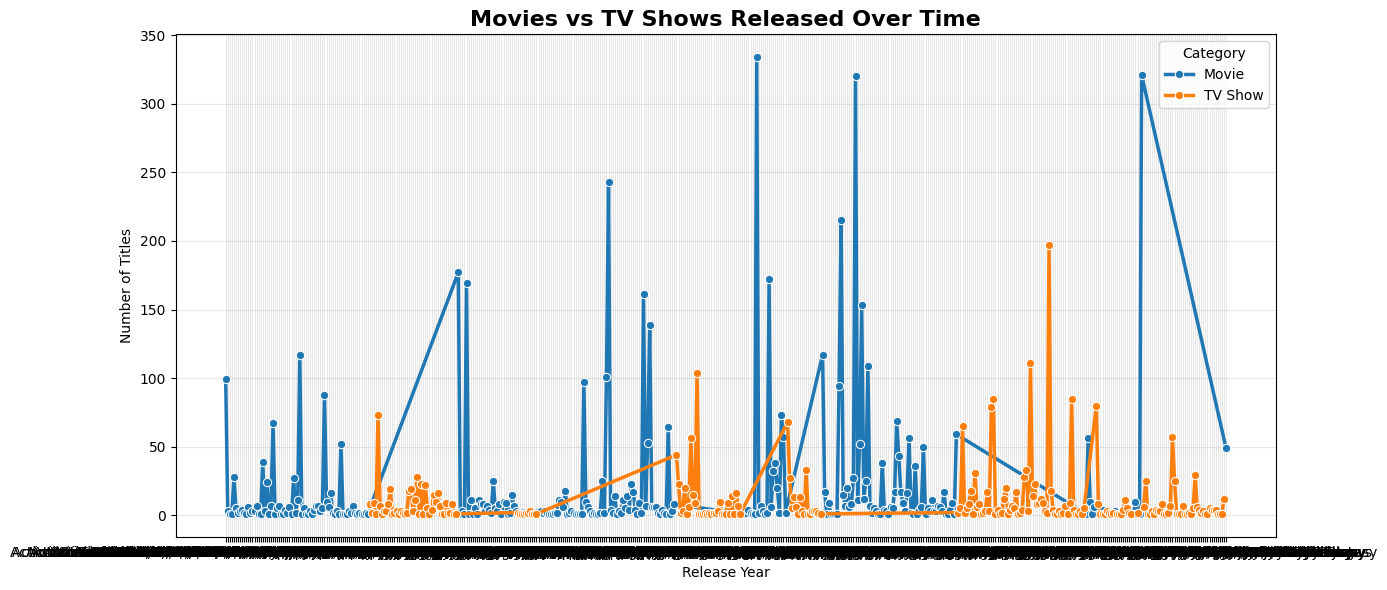

Movies Released
5377.0

TV Shows Released
2312.0


In [35]:
movie_tv_trend = (
    df.groupby(["Type", "Category"])
      .size()
      .reset_index(name="Total Titles")
)

movie_tv_trend.head()

movie_tv_pivot = (
    movie_tv_trend
    .pivot(
        index="Type",
        columns="Category",
        values="Total Titles"
    )
    .fillna(0)
)

movie_tv_pivot.head()

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14,6))

sns.lineplot(
    data=movie_tv_trend,
    x="Type",
    y="Total Titles",
    hue="Category",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title(
    "Movies vs TV Shows Released Over Time",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Titles")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "./charts/movies_vs_tvshows_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Movies Released")

print(movie_tv_pivot["Movie"].sum())

print("\nTV Shows Released")

print(movie_tv_pivot["TV Show"].sum())

🎬 Shortest Movie Details

Title         : Silent
Director      : Limbert Fabian, Brandon Oldenburg
Country       : United States
Release Year  : Children & Family Movies, Sci-Fi & Fantasy
Duration      : 3 Minutes
Rating        : TV-Y


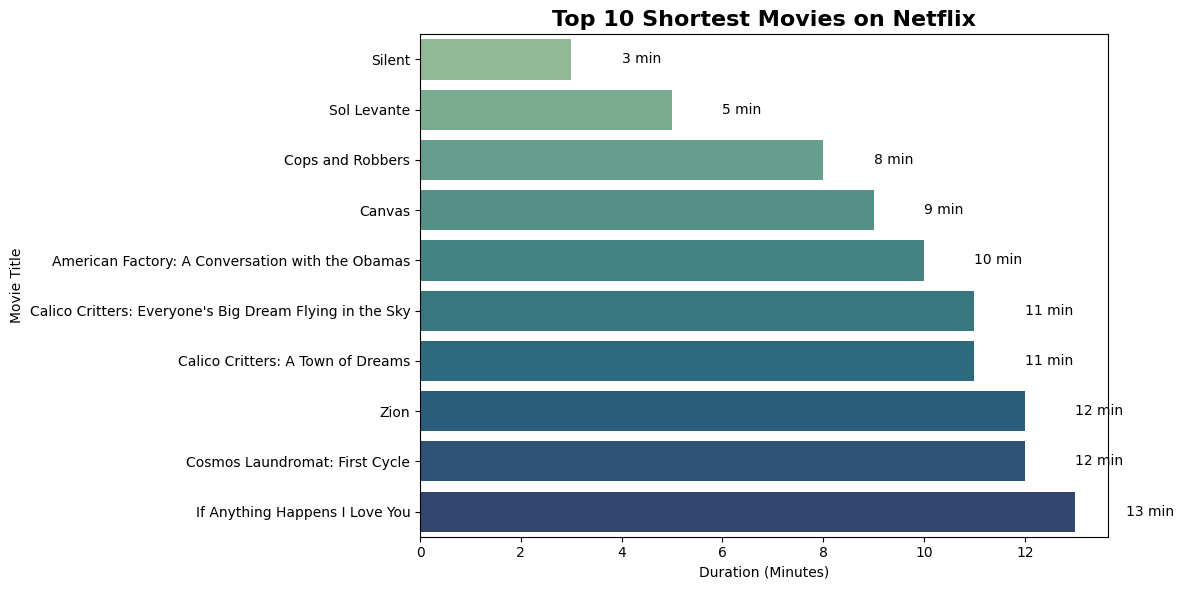

Silent
3


In [34]:
shortest_movie = movies.loc[
    movies["Minutes"].idxmin()
]

shortest_movie

print("🎬 Shortest Movie Details\n")

print(f"Title         : {shortest_movie['Title']}")
print(f"Director      : {shortest_movie['Director']}")
print(f"Country       : {shortest_movie['Country']}")
print(f"Release Year  : {shortest_movie['Type']}")
print(f"Duration      : {shortest_movie['Minutes']} Minutes")
print(f"Rating        : {shortest_movie['Rating']}")

top10_shortest = (
    movies[
        [
            "Title",
            "Minutes",
            "Director",
            "Country"
        ]
    ]
    .sort_values(
        by="Minutes",
        ascending=True
    )
    .head(10)
)

top10_shortest

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=top10_shortest,
    x="Minutes",
    y="Title",
    hue="Title",
    palette="crest",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 10 Shortest Movies on Netflix",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Duration (Minutes)")
ax.set_ylabel("Movie Title")

for i, value in enumerate(top10_shortest["Minutes"]):
    ax.text(
        value + 1,
        i,
        f"{value} min",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "./charts/top10_shortest_movies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

shortest_movie_title = shortest_movie["Title"]

shortest_movie_duration = shortest_movie["Minutes"]

print(shortest_movie_title)
print(shortest_movie_duration)

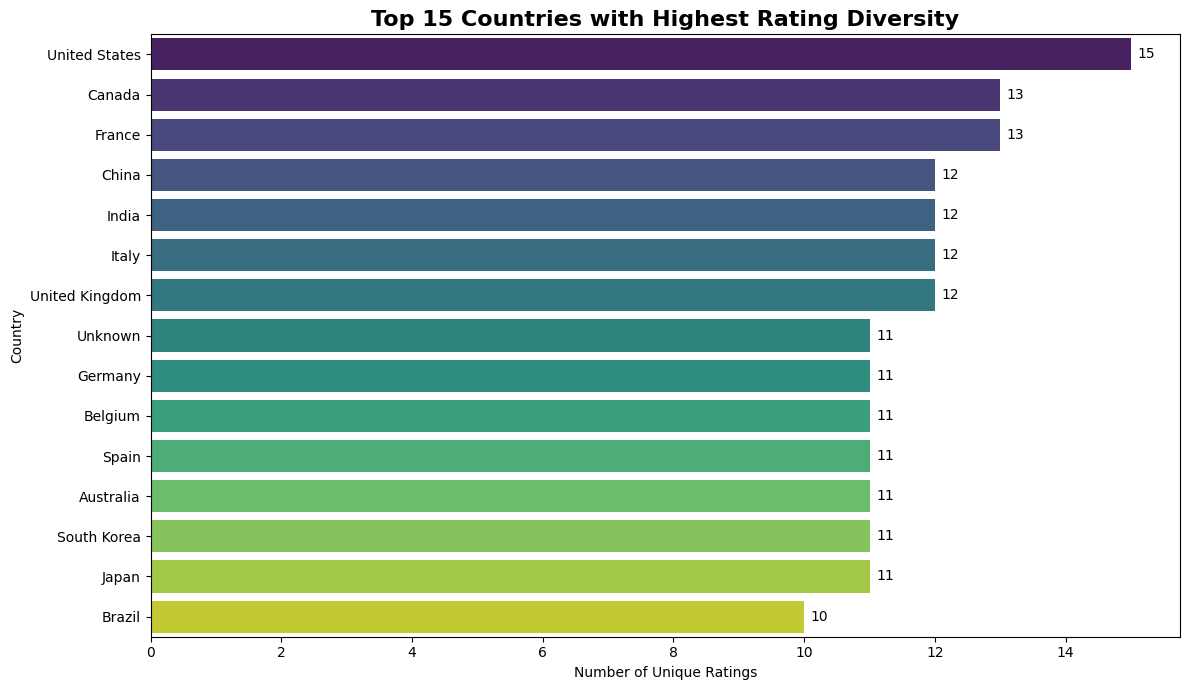

Country : United States
Unique Ratings : 15


In [33]:
country_rating = (
    df.dropna(subset=["Country", "Rating"])
      .assign(Country=df["Country"].str.split(", "))
      .explode("Country")
)

country_rating.head()

rating_diversity = (
    country_rating
    .groupby("Country")["Rating"]
    .nunique()
    .reset_index(name="Unique Ratings")
    .sort_values(
        by="Unique Ratings",
        ascending=False
    )
)

rating_diversity.head(15)

top15_diversity = rating_diversity.head(15)

top15_diversity

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,7))

sns.barplot(
    data=top15_diversity,
    x="Unique Ratings",
    y="Country",
    hue="Country",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 15 Countries with Highest Rating Diversity",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Number of Unique Ratings")
ax.set_ylabel("Country")

for i, value in enumerate(top15_diversity["Unique Ratings"]):
    ax.text(
        value + 0.1,
        i,
        str(value),
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "./charts/rating_diversity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

highest_diversity_country = top15_diversity.iloc[0]["Country"]

highest_diversity = top15_diversity.iloc[0]["Unique Ratings"]

print(f"Country : {highest_diversity_country}")

print(f"Unique Ratings : {highest_diversity}")

Average Title Length : 17.66 Characters


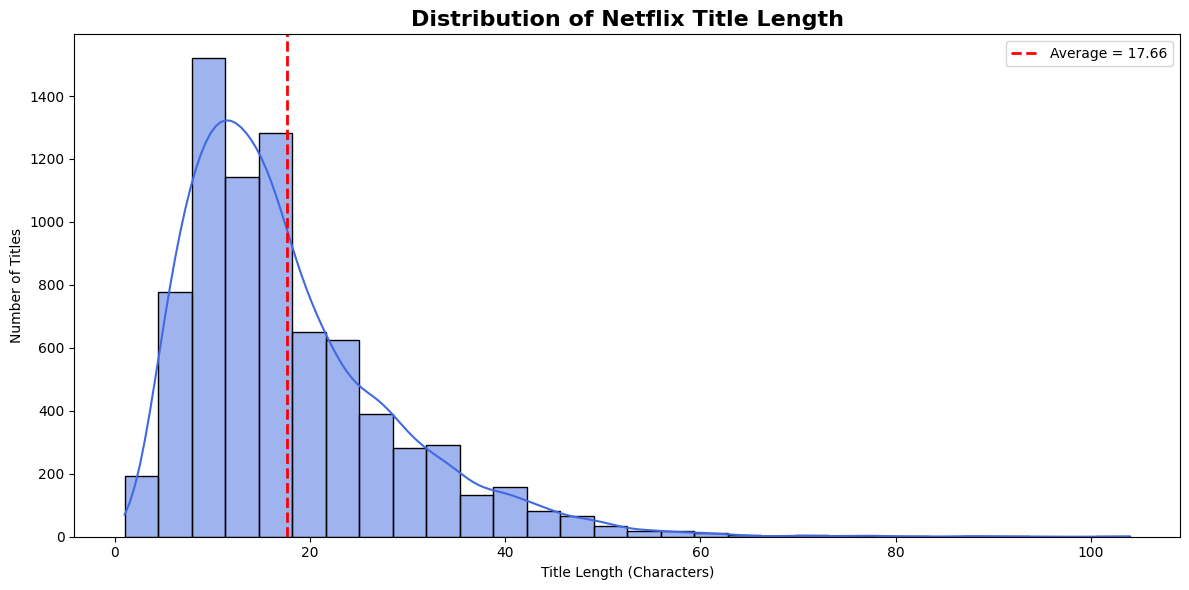

17.662374821173106

In [31]:
df["Title Length"] = df["Title"].str.len()

df[["Title", "Title Length"]].head()

title_stats = df["Title Length"].describe()

title_stats

longest_titles = (
    df[["Title", "Title Length", "Category"]]
    .sort_values(
        by="Title Length",
        ascending=False
    )
    .head(10)
)

longest_titles

shortest_titles = (
    df[["Title", "Title Length", "Category"]]
    .sort_values(
        by="Title Length",
        ascending=True
    )
    .head(10)
)

shortest_titles

average_title_length = df["Title Length"].mean()

print(f"Average Title Length : {average_title_length:.2f} Characters")

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,6))

sns.histplot(
    data=df,
    x="Title Length",
    bins=30,
    kde=True,
    color="royalblue",
    ax=ax
)

ax.axvline(
    average_title_length,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average = {average_title_length:.2f}"
)

ax.set_title(
    "Distribution of Netflix Title Length",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Title Length (Characters)")
ax.set_ylabel("Number of Titles")

ax.legend()

plt.tight_layout()

plt.savefig(
    "./charts/title_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

longest_title = longest_titles.iloc[0]["Title"]

longest_title_length = longest_titles.iloc[0]["Title Length"]

average_title_length

In [37]:
!pip install wordcloud

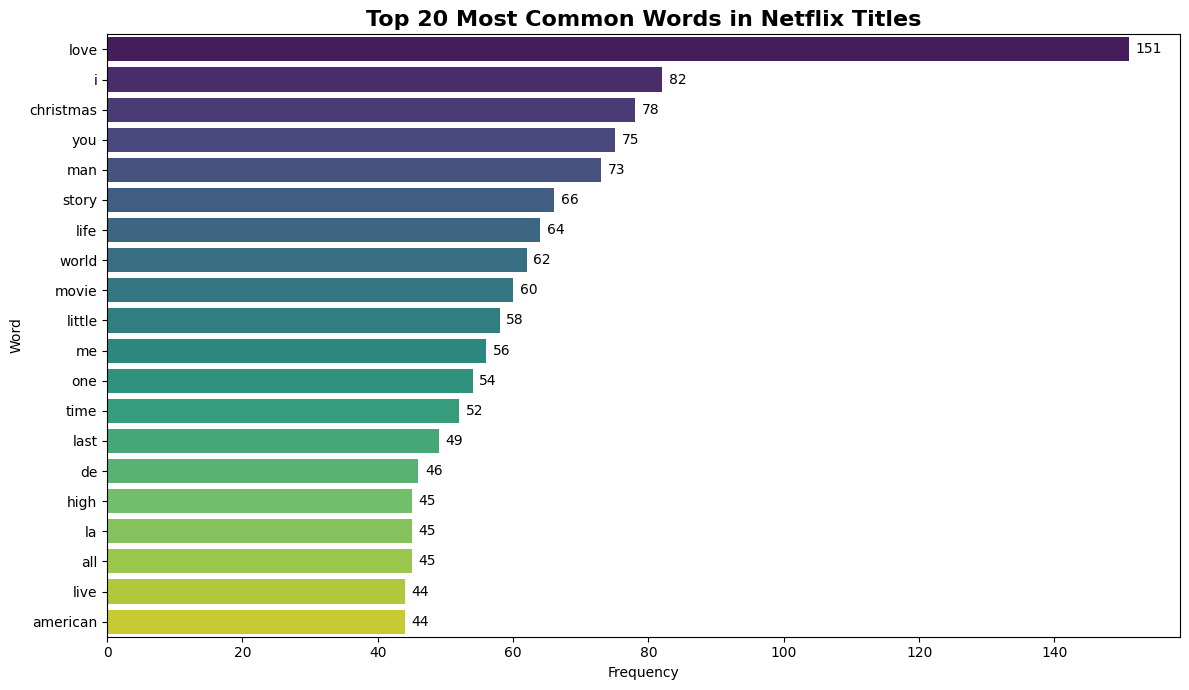

love
151


In [38]:
from collections import Counter
from wordcloud import WordCloud
import re

stop_words = {
    "the","a","an","of","and","to","in","on",
    "for","with","at","by","from","is","are",
    "or","as","into","its","your","my","our"
}

titles = (
    df["Title"]
    .dropna()
    .str.lower()
)

titles.head()

words = []

for title in titles:

    # Remove punctuation
    title = re.sub(r"[^a-zA-Z ]", "", title)

    # Split into words
    title_words = title.split()

    # Remove stop words
    title_words = [
        word for word in title_words
        if word not in stop_words
    ]

    words.extend(title_words)

word_frequency = (
    pd.DataFrame(
        Counter(words).most_common(20),
        columns=["Word","Frequency"]
    )
)

word_frequency

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,7))

sns.barplot(
    data=word_frequency,
    x="Frequency",
    y="Word",
    hue="Word",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 20 Most Common Words in Netflix Titles",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Frequency")
ax.set_ylabel("Word")

for i, value in enumerate(word_frequency["Frequency"]):
    ax.text(
        value + 1,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "./charts/common_title_words.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

most_common_word = word_frequency.iloc[0]["Word"]

most_common_frequency = word_frequency.iloc[0]["Frequency"]

print(most_common_word)
print(most_common_frequency)

Average Description Length : 143.10 Characters


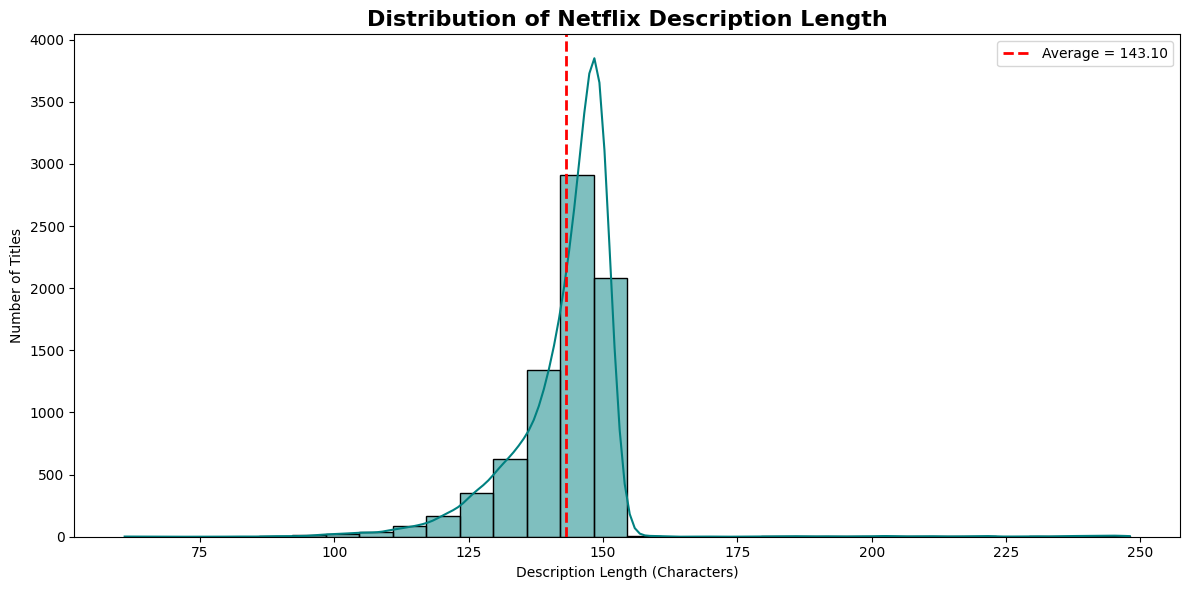

248

In [39]:
df["Description Length"] = (
    df["Description"]
    .fillna("")
    .str.len()
)

df[["Title", "Description Length"]].head()

description_stats = df["Description Length"].describe()

description_stats

average_description_length = df["Description Length"].mean()

print(f"Average Description Length : {average_description_length:.2f} Characters")

longest_description = (
    df[
        [
            "Title",
            "Category",
            "Description Length"
        ]
    ]
    .sort_values(
        by="Description Length",
        ascending=False
    )
    .head(10)
)

longest_description

shortest_description = (
    df[
        [
            "Title",
            "Category",
            "Description Length"
        ]
    ]
    .sort_values(
        by="Description Length",
        ascending=True
    )
    .head(10)
)

shortest_description

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,6))

sns.histplot(
    data=df,
    x="Description Length",
    bins=30,
    kde=True,
    color="teal",
    ax=ax
)

ax.axvline(
    average_description_length,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average = {average_description_length:.2f}"
)

ax.set_title(
    "Distribution of Netflix Description Length",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Description Length (Characters)")
ax.set_ylabel("Number of Titles")

ax.legend()

plt.tight_layout()

plt.savefig(
    "./charts/description_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

average_description_length

longest_description.iloc[0]["Title"]

longest_description.iloc[0]["Description Length"]

Total Duplicate Titles : 0


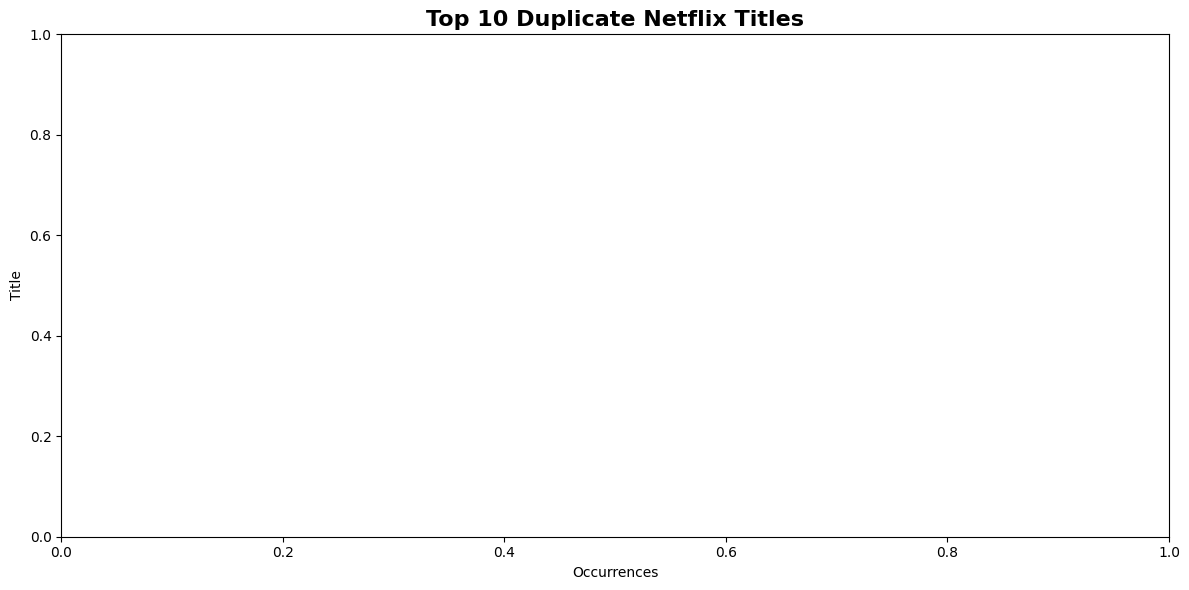

Unique Titles : 7689
Duplicate Titles : 0


In [40]:
duplicate_count = df["Title"].duplicated().sum()

print(f"Total Duplicate Titles : {duplicate_count}")

duplicate_titles = (
    df[df["Title"].duplicated(keep=False)]
    .sort_values("Title")
)

duplicate_titles

duplicate_frequency = (
    df["Title"]
    .value_counts()
    .reset_index()
)

duplicate_frequency.columns = [
    "Title",
    "Count"
]

duplicate_frequency = duplicate_frequency[
    duplicate_frequency["Count"] > 1
]

duplicate_frequency

top_duplicate_titles = (
    duplicate_frequency
    .sort_values(
        by="Count",
        ascending=False
    )
    .head(10)
)

top_duplicate_titles

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=top_duplicate_titles,
    x="Count",
    y="Title",
    hue="Title",
    palette="rocket",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 10 Duplicate Netflix Titles",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Occurrences")
ax.set_ylabel("Title")

for i, value in enumerate(top_duplicate_titles["Count"]):
    ax.text(
        value + 0.05,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "./charts/duplicate_titles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

unique_titles = df["Title"].nunique()

duplicate_titles_count = duplicate_count

print(f"Unique Titles : {unique_titles}")
print(f"Duplicate Titles : {duplicate_titles_count}")

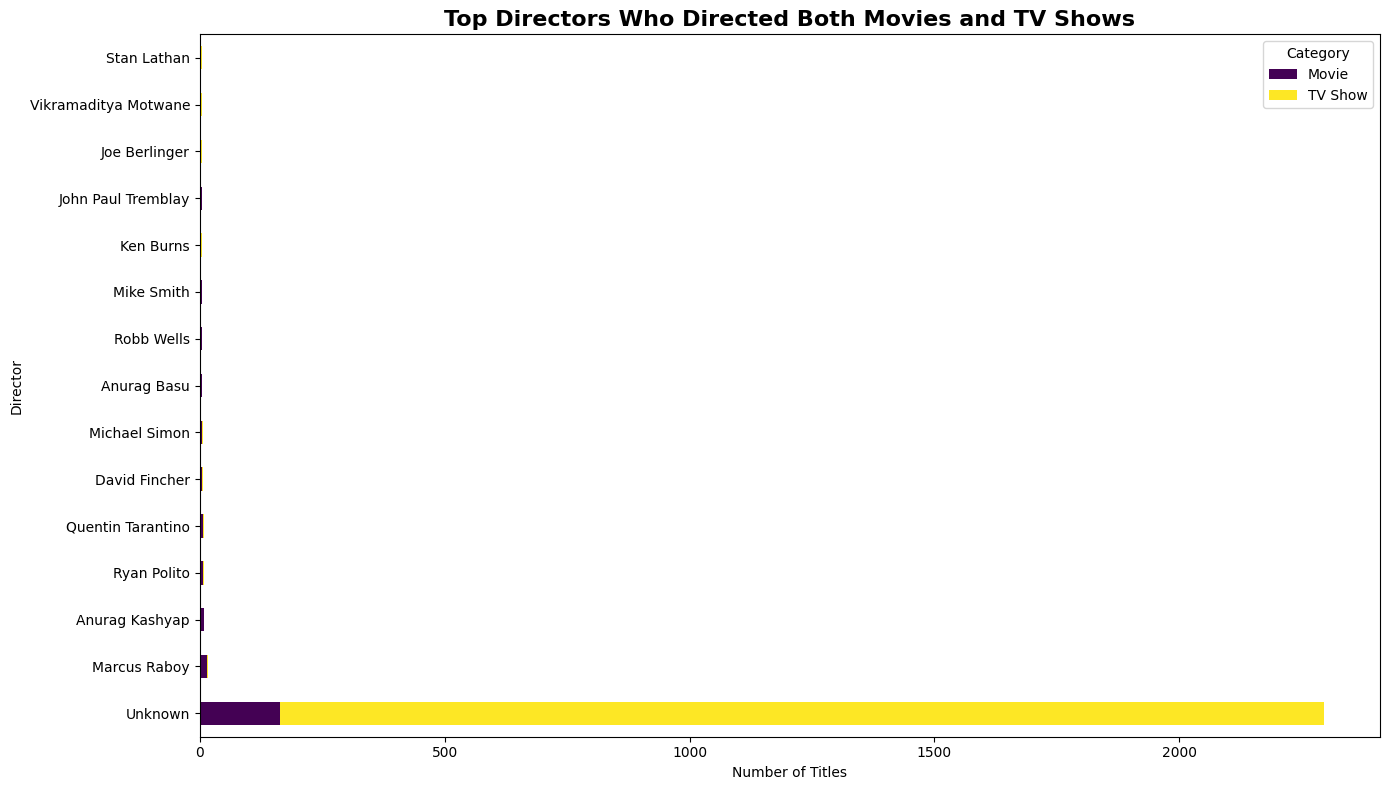

Directors with both Movies & TV Shows : 61
Top Director : Unknown


In [41]:
director_data = (
    df.dropna(subset=["Director"])
      .assign(Director=df["Director"].str.split(", "))
      .explode("Director")
)

director_data.head()

director_category = (
    director_data
    .groupby("Director")["Category"]
    .nunique()
    .reset_index(name="Category Count")
)

both_directors = director_category[
    director_category["Category Count"] == 2
]

both_directors.head()

director_summary = (
    director_data[
        director_data["Director"].isin(
            both_directors["Director"]
        )
    ]
    .groupby(["Director", "Category"])
    .size()
    .unstack(fill_value=0)
)

director_summary.head()

director_summary["Total Titles"] = (
    director_summary["Movie"] +
    director_summary["TV Show"]
)

director_summary = director_summary.sort_values(
    by="Total Titles",
    ascending=False
)

director_summary.head(15)

top15_directors_both = (
    director_summary
    .head(15)
    .reset_index()
)

top15_directors_both

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,8))

top15_directors_both.set_index("Director")[
    ["Movie", "TV Show"]
].plot(
    kind="barh",
    stacked=True,
    ax=ax,
    colormap="viridis"
)

ax.set_title(
    "Top Directors Who Directed Both Movies and TV Shows",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Number of Titles")
ax.set_ylabel("Director")

plt.tight_layout()

plt.savefig(
    "./charts/directors_movies_tvshows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

total_directors_both = len(both_directors)

top_director_both = top15_directors_both.iloc[0]["Director"]

print(f"Directors with both Movies & TV Shows : {total_directors_both}")

print(f"Top Director : {top_director_both}")

Family Friendly : 1793
Mature : 5896


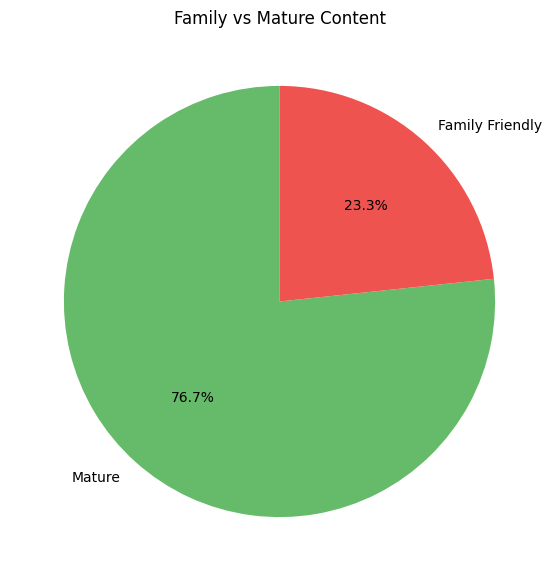

In [42]:
family_ratings = [
    "G",
    "PG",
    "TV-G",
    "TV-Y",
    "TV-Y7",
    "TV-PG"
]

df["Content Group"] = df["Rating"].apply(
    lambda x: "Family Friendly"
    if x in family_ratings
    else "Mature"
)

df[["Rating", "Content Group"]].head()

content_group = (
    df["Content Group"]
    .value_counts()
    .reset_index()
)

content_group.columns = [
    "Content Group",
    "Total Titles"
]

content_group

family_titles = len(
    df[df["Content Group"] == "Family Friendly"]
)

mature_titles = len(
    df[df["Content Group"] == "Mature"]
)

print(f"Family Friendly : {family_titles}")

print(f"Mature : {mature_titles}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,7))

ax.pie(
    content_group["Total Titles"],
    labels=content_group["Content Group"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66BB6A", "#EF5350"]
)

ax.set_title(
    "Family vs Mature Content"
)

plt.savefig(
    "./charts/family_vs_mature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Country : United States
Mature Titles : 2401


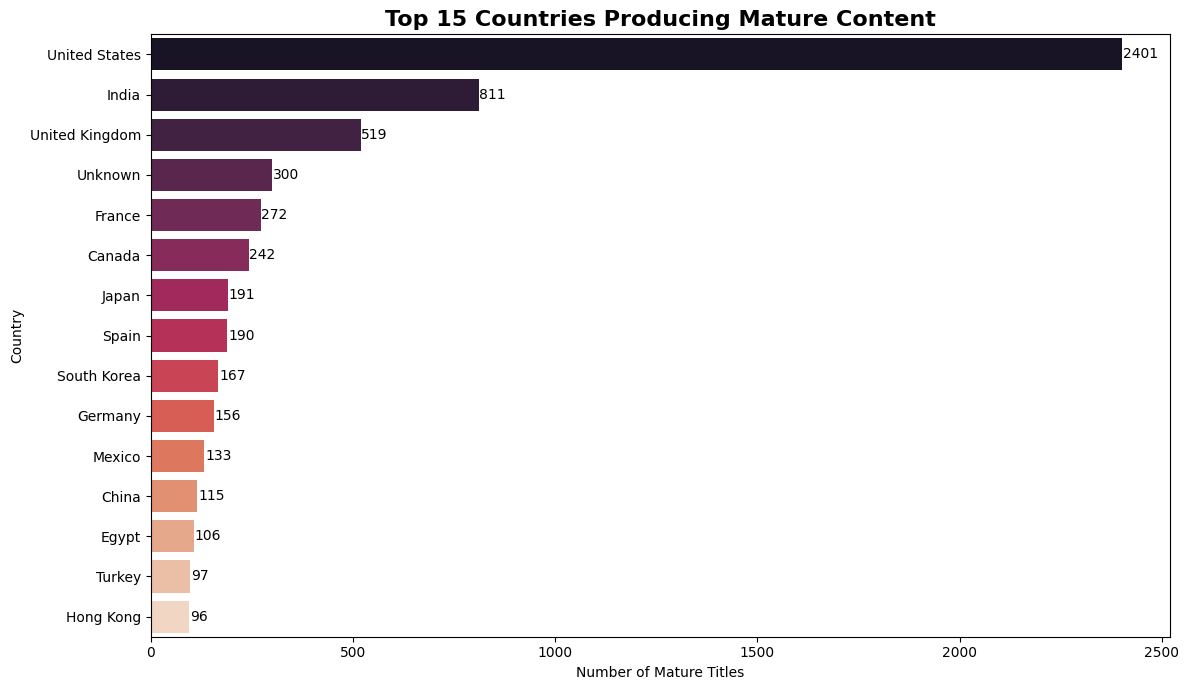

In [43]:
mature_df = df[
    df["Content Group"] == "Mature"
].copy()

mature_df.head()

mature_country = (
    mature_df
    .dropna(subset=["Country"])
    .assign(
        Country=mature_df["Country"].str.split(", ")
    )
    .explode("Country")
)

mature_country.head()

top_mature_country = (
    mature_country["Country"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_mature_country.columns = [
    "Country",
    "Mature Titles"
]

top_mature_country

highest_mature_country = top_mature_country.iloc[0]["Country"]

highest_mature_titles = top_mature_country.iloc[0]["Mature Titles"]

print(f"Country : {highest_mature_country}")

print(f"Mature Titles : {highest_mature_titles}")

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,7))

sns.barplot(
    data=top_mature_country,
    x="Mature Titles",
    y="Country",
    hue="Country",
    palette="rocket",
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 15 Countries Producing Mature Content",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Number of Mature Titles")

ax.set_ylabel("Country")

for i, value in enumerate(top_mature_country["Mature Titles"]):
    ax.text(
        value + 2,
        i,
        str(value),
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "./charts/mature_content_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Total Titles : 7689
Movies : 5377
TV Shows : 2312
Top Country : United States
Top Director : Jan Suter
Average Duration : 99.31


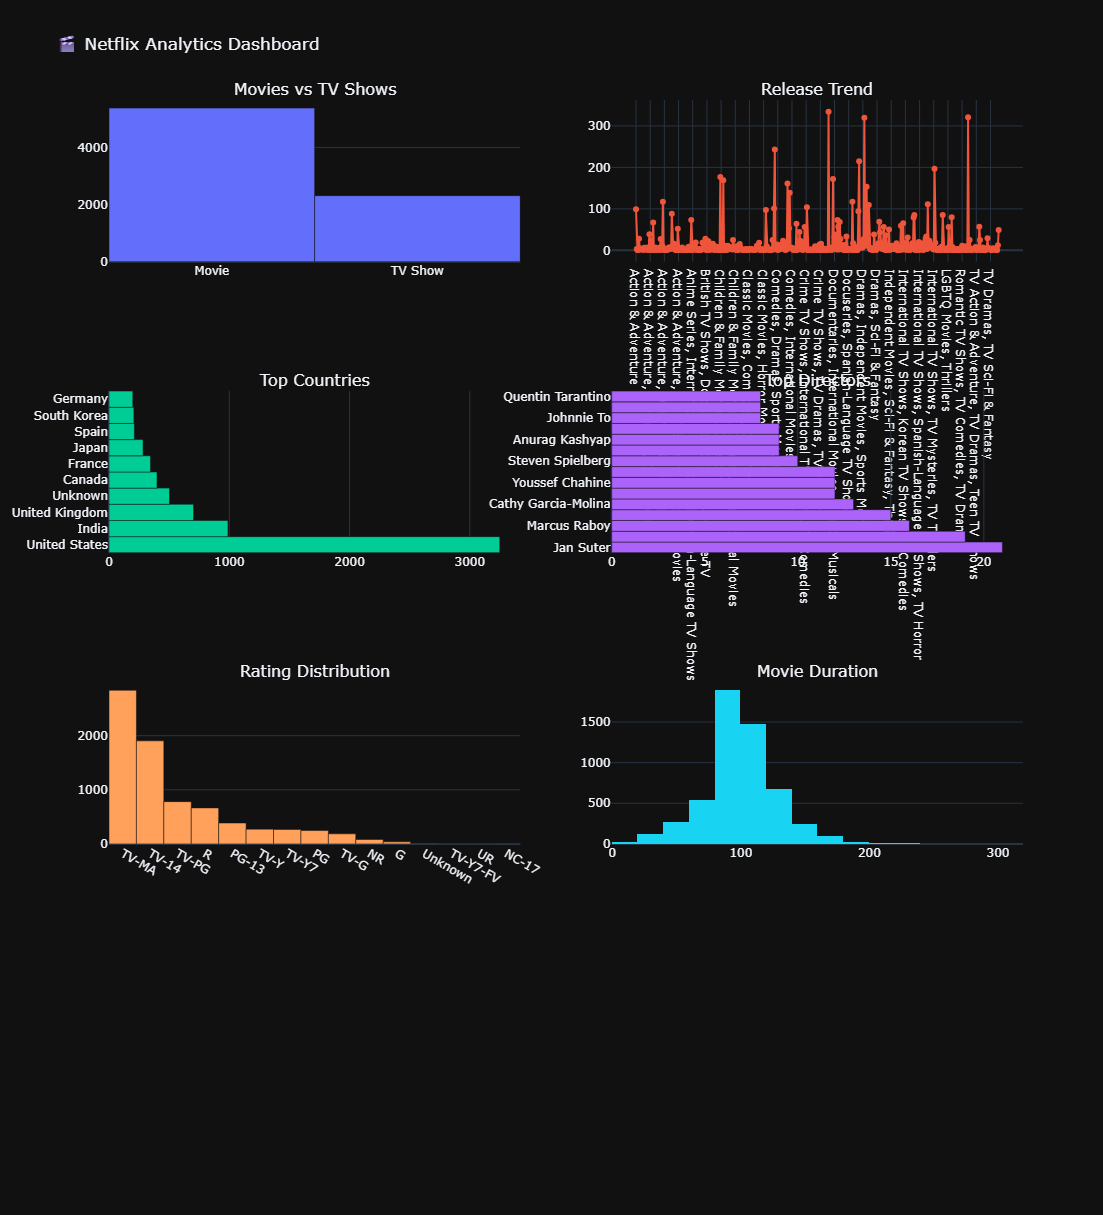

In [44]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

fig = make_subplots(
    rows=4,
    cols=2,

    subplot_titles=(

        "Movies vs TV Shows",

        "Release Trend",

        "Top Countries",

        "Top Directors",

        "Rating Distribution",

        "Movie Duration"

    )
)

print("Total Titles :", total_titles)

print("Movies :", total_movies)

print("TV Shows :", total_tvshows)

print("Top Country :", top_country)

print("Top Director :", top_director)

print("Average Duration :", round(average_duration,2))

fig.add_trace(

    go.Bar(

        x=content_distribution["Content Type"],

        y=content_distribution["Total Titles"],

        name="Content"

    ),

    row=1,
    col=1
)

fig.add_trace(

    go.Scatter(

        x=release_trend["Type"],

        y=release_trend["Total Titles"],

        mode="lines+markers",

        name="Release Trend"

    ),

    row=1,
    col=2
)

fig.add_trace(

    go.Bar(

        x=top_countries["Content Count"],

        y=top_countries["Country"],

        orientation="h",

        name="Countries"

    ),

    row=2,
    col=1
)

fig.add_trace(

    go.Bar(

        x=top15_directors["Total Titles"],

        y=top15_directors["Director"],

        orientation="h",

        name="Director"

    ),

    row=2,
    col=2
)

fig.add_trace(

    go.Bar(

        x=rating_distribution["Rating"],

        y=rating_distribution["Count"],

        name="Ratings"

    ),

    row=3,
    col=1
)

fig.add_trace(

    go.Histogram(

        x=movies["Minutes"],

        nbinsx=30,

        name="Duration"

    ),

    row=3,
    col=2
)

fig.update_layout(

    title="🎬 Netflix Analytics Dashboard",

    height=1200,

    width=1500,

    template="plotly_dark",

    showlegend=False
)

fig.show()

Dataset Summary
----------------------------------------
Total Records       : 7689
Total Features      : 15
Movies              : 5377
TV Shows            : 2312
Countries           : 678
Directors           : 4047
Actors              : 6745
Ratings             : 15


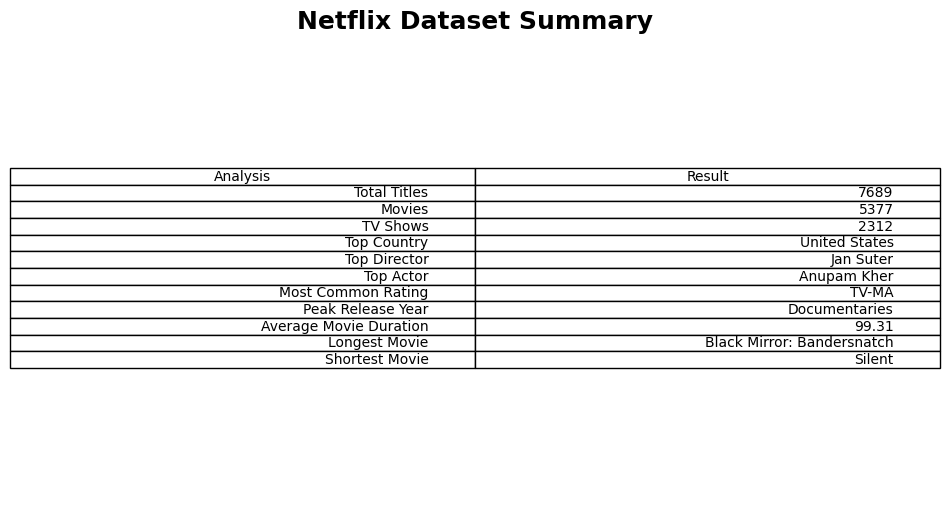

In [46]:
print("Dataset Summary")

print("-" * 40)

print(f"Total Records       : {len(df)}")

print(f"Total Features      : {df.shape[1]}")

print(f"Movies              : {total_movies}")

print(f"TV Shows            : {total_tvshows}")

print(f"Countries           : {df['Country'].nunique()}")

print(f"Directors           : {df['Director'].nunique()}")

print(f"Actors              : {df['Cast'].nunique()}")

print(f"Ratings             : {df['Rating'].nunique()}")

total_titles = len(df)
total_movies = len(df[df["Category"] == "Movie"])
total_tvshows = len(df[df["Category"] == "TV Show"])

longest_movie = movies.loc[movies["Minutes"].idxmax()]
shortest_movie = movies.loc[movies["Minutes"].idxmin()]

longest_movie_title = longest_movie["Title"]
shortest_movie_title = shortest_movie["Title"]

average_duration = movies["Minutes"].mean()

eda_summary = pd.DataFrame({

    "Analysis":[

        "Total Titles",

        "Movies",

        "TV Shows",

        "Top Country",

        "Top Director",

        "Top Actor",

        "Most Common Rating",

        "Peak Release Year",

        "Average Movie Duration",

        "Longest Movie",

        "Shortest Movie"

    ],

    "Result":[

        total_titles,

        total_movies,

        total_tvshows,

        top_country,

        top_director,

        top_actor,

        top_rating,

        peak_release_year,

        round(average_duration,2),

        longest_movie_title,

        shortest_movie_title

    ]

})

eda_summary

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.axis("off")

plt.table(

    cellText=eda_summary.values,

    colLabels=eda_summary.columns,

    loc="center"

)

plt.title(

    "Netflix Dataset Summary",

    fontsize=18,

    fontweight="bold"

)

plt.savefig(

    "./charts/eda_summary.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

NameError: name 'recommendations' is not defined

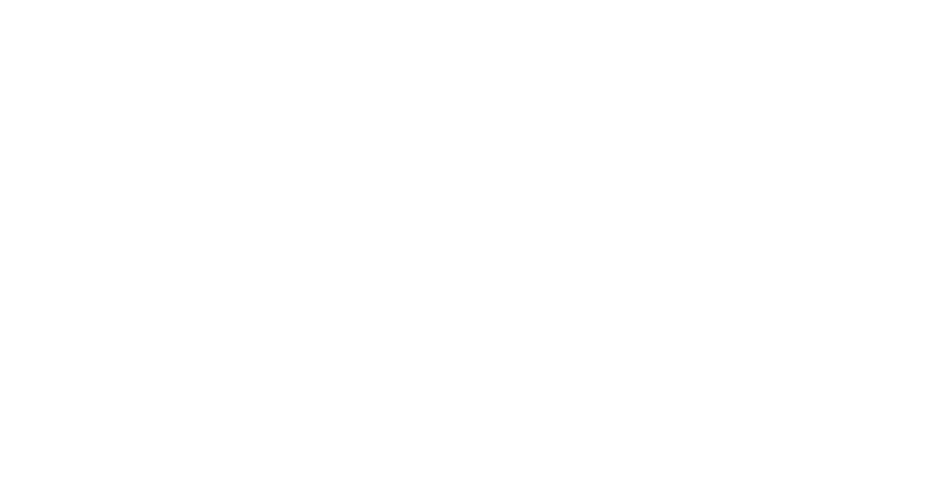

In [47]:
total_titles = len(df)
total_movies = len(df[df["Category"] == "Movie"])
total_tvshows = len(df[df["Category"] == "TV Show"])

longest_movie = movies.loc[movies["Minutes"].idxmax()]
shortest_movie = movies.loc[movies["Minutes"].idxmin()]

longest_movie_title = longest_movie["Title"]
shortest_movie_title = shortest_movie["Title"]

average_duration = movies["Minutes"].mean()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

ax.axis("off")

table = ax.table(
    cellText=recommendations.values,
    colLabels=recommendations.columns,
    cellLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2)

plt.title(
    "Netflix Business Recommendations",
    fontsize=18,
    fontweight="bold"
)

plt.savefig(
    "./charts/business_recommendations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()